# **F1 Racing Pit Stop Predictions**

## **Setup**
*Load python packages and data needed for the project and preview the data*

- Load python packages and the data needed for project
- Preview data, identify data types, and check for missing values

In [ ]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
print(f"Libraries imported successfully.\n")

# Load the data
train_raw = pd.read_csv('Data/train.csv')
test_raw = pd.read_csv('Data/test.csv')

# Display the first few rows of the training data
print(train_raw.head())
# Display the column names and data types
print(train_raw.info())
# Check for missing values in the training data
print(train_raw.isnull().sum())
# Check for missing values in the test data
print(test_raw.isnull().sum())

# Change data type of 'PitNextLap' to integer
train_raw['PitNextLap'] = train_raw['PitNextLap'].astype(int)

Libraries imported successfully.

   id Driver Compound                   Race  Year  PitStop  LapNumber  Stint  \
0   0   D109     HARD    Canadian Grand Prix  2022        0         50      2   
1   1   D086     HARD       Dutch Grand Prix  2025        1         27      2   
2   2    ZON     HARD    Austrian Grand Prix  2022        0         59      3   
3   3    SPE   MEDIUM     Pre-Season Testing  2023        0          2      1   
4   4   D019     HARD  Azerbaijan Grand Prix  2022        1         26      3   

   TyreLife  Position  LapTime (s)  LapTime_Delta  Cumulative_Degradation  \
0      39.0         8       78.491         -7.564                  21.019   
1       7.0         4       75.095        -32.617                -223.207   
2      22.0        13       70.945         -7.540                -100.529   
3       2.0         7       94.361         -7.324                  -7.324   
4       6.0         2      107.878          8.965                 -14.139   

   RaceProgress 

## **EDA**
*Detailed analysis of the structure of data used in the project and how predictor variables relate to target variable (PitNextStop)*

### **Variable Description**

| Variable | Data Type | Definition |
|:---|:---:|:---|
| id | Integer | Unique row identifier for each lap observation |
| Driver | String | Anonymized driver code (e.g. D109, ZON) |
| Compound | String | Tyre compound in use: SOFT, MEDIUM, HARD, INTERMEDIATE, or WET |
| Race | String | Name of the Grand Prix (e.g. Canadian Grand Prix) |
| Year | Integer | Season year (2022–2025) |
| PitStop | Integer | Binary flag indicating whether a pit stop occurred on the current lap |
| LapNumber | Integer | The lap number within the race |
| Stint | Integer | Stint number (increments after each pit stop) |
| TyreLife | Float | Number of laps the current set of tyres has been in use |
| Position | Integer | Driver's race position at the end of the lap |
| LapTime (s) | Float | Lap time in seconds |
| LapTime_Delta | Float | Difference in lap time relative to the previous lap (seconds); positive = slower |
| Cumulative_Degradation | Float | Running sum of lap time deltas across the current stint — captures compound tyre wear |
| RaceProgress | Float | Proportion of the race completed (0.0 = start, 1.0 = finish) |
| Position_Change | Float | Change in race position since the previous lap; negative = gained places |
| PitNextLap | Integer | **Target variable** — 1 if the driver pitted on the following lap, 0 otherwise |


### **Descriptive Stats**

In [30]:
def create_descriptive_stats(df):
    """
    Create a descriptive statistics table for all columns in a DataFrame.
    
    Parameters:
        df (pd.DataFrame): The input DataFrame.
    
    Returns:
        pd.DataFrame: A table with statistics for each column.
    """
    stats = []
    
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            stats.append({
                'column': col,
                'mean': df[col].mean(),
                'median': df[col].median(),
                'stdev': df[col].std(),
                'min': df[col].min(),
                'max': df[col].max(),
                'na_vals': df[col].isnull().sum()
            })
        else:
            stats.append({
                'column': col,
                'mean': 'N/A',
                'median': 'N/A',
                'stdev': 'N/A',
                'min': 'N/A',
                'max': 'N/A',
                'na_vals': df[col].isnull().sum()
            })
    
    return pd.DataFrame(stats)

display(create_descriptive_stats(train_raw))

,column,mean,median,stdev,min,max,na_vals
0,id,219569.5,219569.5,126768.942943,0,439139,0
1,Driver,N/A,N/A,N/A,N/A,N/A,0
2,Compound,N/A,N/A,N/A,N/A,N/A,0
3,Race,N/A,N/A,N/A,N/A,N/A,0
4,Year,2023.523544,2024.0,1.02493,2022,2025,0
5,PitStop,0.136118,0.0,0.342915,0,1,0
6,LapNumber,23.105909,19.0,16.958261,1,78,0
7,Stint,1.789113,2.0,0.950194,1,8,0
8,TyreLife,14.158231,12.0,9.801338,1.0,77.0,0
9,Position,9.630339,10.0,5.27877,1,20,0


### **Data Distribution**

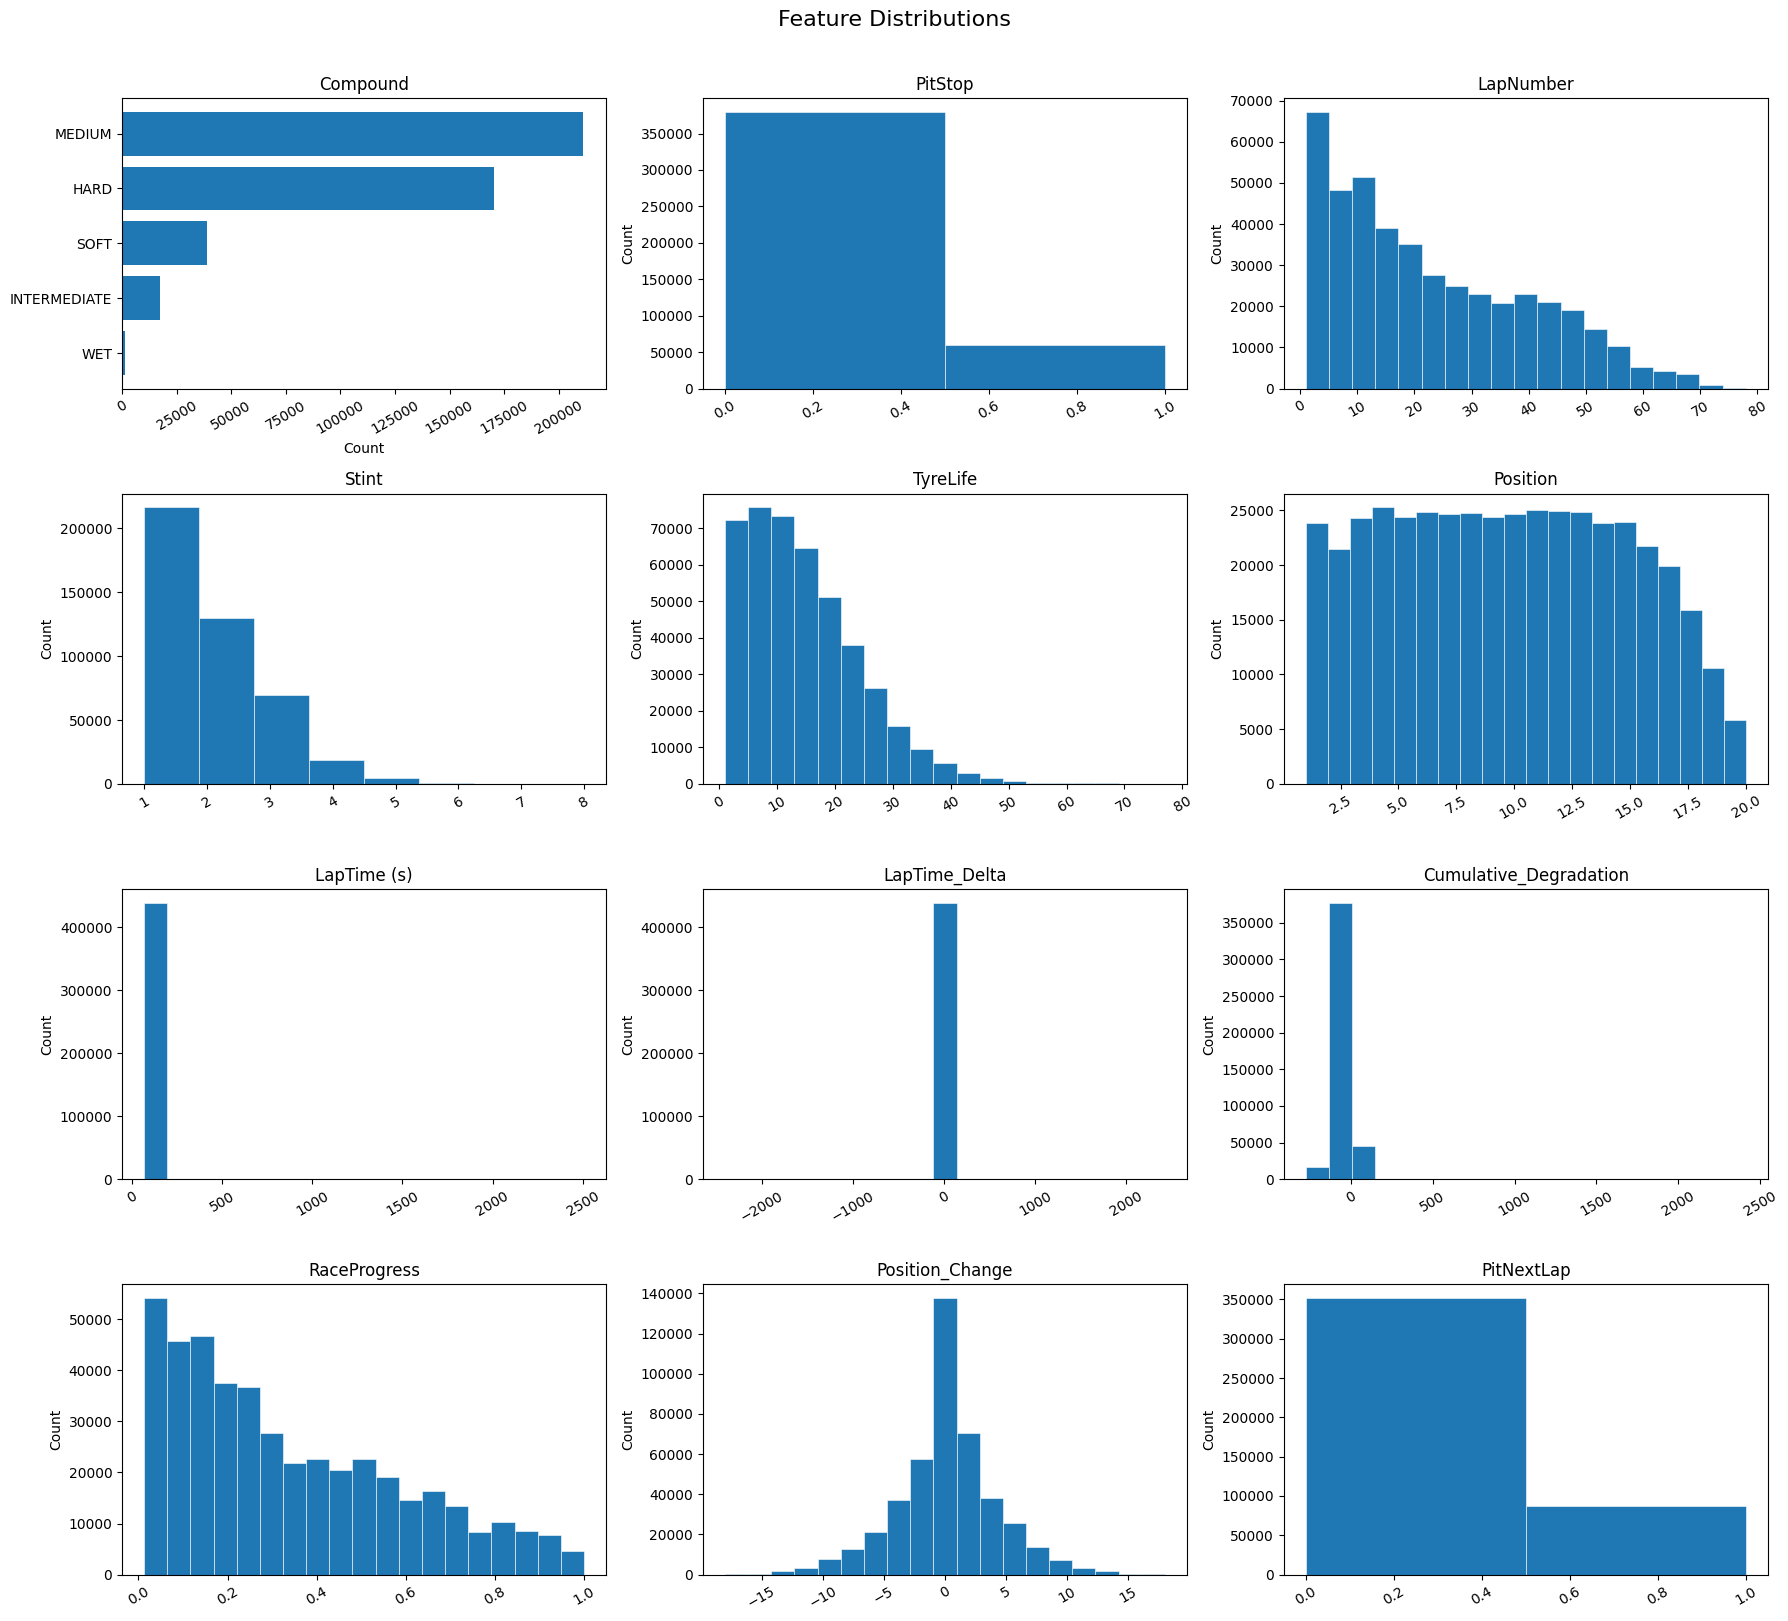

In [ ]:
def plot_distributions(df, skip_columns):
    """
    Plot the distribution of every column in df, skipping any named in skip_columns.

    - String columns: horizontal bar chart of value frequencies
    - Numeric columns: bin count adapts to the number of unique values
        - Binary (2 unique values): 2 bins
        - Low-cardinality integers (<=30 unique): one bin per unique value
        - Everything else: Sturges' rule capped at 80
    """

    cols_to_plot = [c for c in df.columns if c not in skip_columns]
    n = len(cols_to_plot)
    ncols = 3
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols,
                             figsize=(6 * ncols, 4 * nrows))
    axes = axes.flatten()

    for i, col in enumerate(cols_to_plot):
        ax = axes[i]
        series = df[col].dropna()

        if series.dtype == object:  # string columns
            counts = series.value_counts()
            ax.barh(counts.index.astype(str), counts.values)
            ax.set_xlabel('Count')
            ax.invert_yaxis()

        else:
            n_unique = series.nunique()

            if n_unique <= 2:
                bins = 2
            elif n_unique <= 30:
                bins = n_unique
            else:
                bins = min(int(math.log2(len(series))) + 1, 80)

            ax.hist(series, bins=bins, edgecolor='white', linewidth=0.4)
            ax.set_ylabel('Count')

        ax.set_title(col)
        ax.tick_params(axis='x', labelrotation=30)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Feature Distributions', fontsize=16, y=1.01)
    plt.tight_layout()
    plt.show()

plot_distributions(train_raw, skip_columns=['id', 'Year', 'Driver', 'Team', 'Race'])

### **Correlation Matrix**

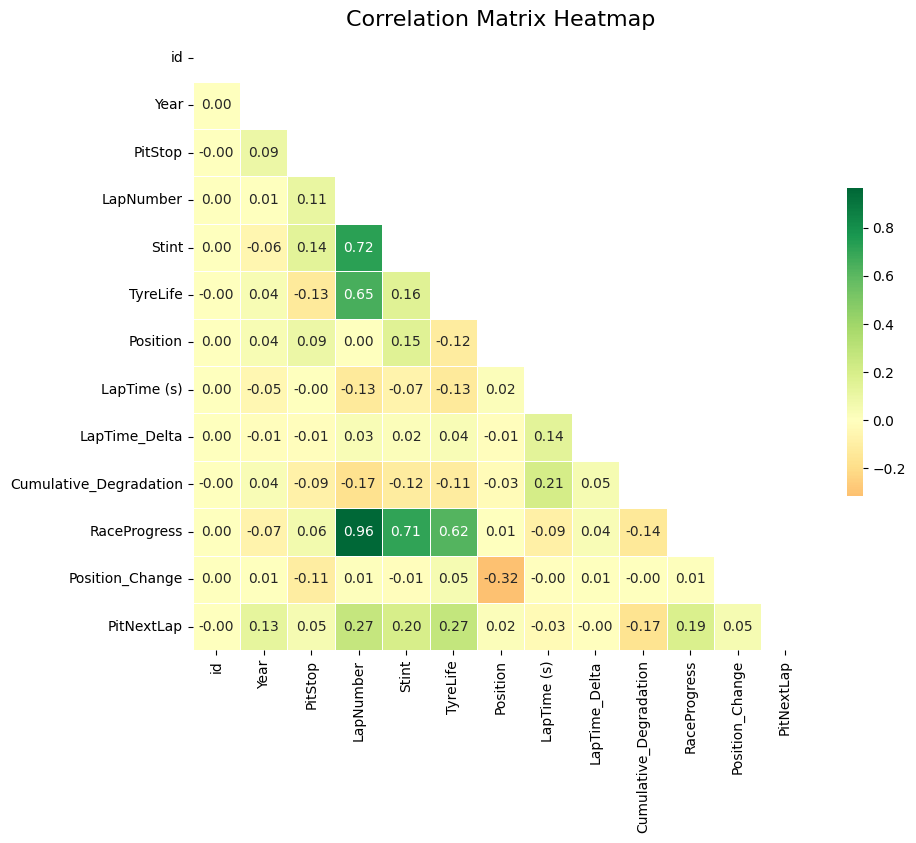

In [36]:
# Write a function that develops a correlation matrix heatmap for the numeric features in the dataset. The function should take a DataFrame as input and return a heatmap plot of the correlation matrix. It should show only the upper triangle of the heatmap and color scale from red to white to green, with red indicating strong negative correlation, white indicating no correlation, and green indicating strong positive correlation. The function should also display the correlation coefficients on the heatmap.
def plot_correlation_heatmap(df):
    """
    Plot a correlation matrix heatmap for the numeric features in the dataset.

    Parameters:
        df (pd.DataFrame): The input DataFrame.

    Returns:
        None: Displays a heatmap plot of the correlation matrix.
    """
    # Select only numeric columns
    numeric_df = df.select_dtypes(include=['number'])
    
    # Compute the correlation matrix
    corr = numeric_df.corr()
    
    # Create a mask for the upper triangle
    mask = np.triu(np.ones_like(corr, dtype=bool))
    
    # Set up the matplotlib figure
    plt.figure(figsize=(10, 8))
    
    # Draw the heatmap with the mask and correct aspect ratio
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='RdYlGn', center=0,
                square=True, linewidths=.5, cbar_kws={"shrink": .5})
    
    plt.title('Correlation Matrix Heatmap', fontsize=16)
    plt.show()
plot_correlation_heatmap(train_raw)

## **Feature Engineering**
*Transform existing variables or create new ones to enhance predictive power of future models*

List of all variables created with description and reason provided indented underneath variable name

In [33]:
def feature_engineering(df):
    """
    Perform feature engineering on the raw DataFrame.
    
    Parameters:
        df_raw (pd.DataFrame): The raw DataFrame containing the data.
    
    Returns:
        pd.DataFrame: The DataFrame with engineered features.
    """
    df = df.copy()


    
    return df
    
train = feature_engineering(train_raw)
test = feature_engineering(test_raw)

## **Modeling**
*Split training data and develop models to predict target variable*

### **Split Training Data**

In [ ]:
FEATURES = [
    'Compound_enc', 'LapNumber', 'Stint', 'TyreLife', 'TyreLife_sq',
    'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation',
    'RaceProgress', 'Position_Change', 'PitStop',
    'LapTime_per_TyreLife', 'ProgressBin', 'InPodium'
]

# X = features, y = target labels
X = train[FEATURES]
y = train['PitNextLap']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set:   {X_train.shape[0]:,} rows")
print(f"Validation set: {X_val.shape[0]:,} rows")
print(f"Class balance (train): {y_train.mean():.3f} positive rate")
print(f"Class balance (val):   {y_val.mean():.3f} positive rate")


### **Model 1: Random Forest**

In [ ]:

def model_1(X_train, y_train, X_val, y_val):
    """
    Train a Random Forest classifier and evaluate on the validation set.
    
    The forest uses 300 trees with moderate depth constraints to balance
    predictive power and overfitting risk. Class weights are balanced
    to account for the ~4:1 class imbalance in the target.
    
    Returns:
        rf_model (RandomForestClassifier): Fitted model
        val_proba (np.ndarray): Predicted probabilities on the validation set
        auc (float): ROC-AUC score on the validation set
    """
    rf_model = RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=10,
        max_features='sqrt',
        class_weight='balanced',
        n_jobs=-1,
        random_state=42
    )

    rf_model.fit(X_train, y_train)
    val_proba = rf_model.predict_proba(X_val)[:, 1]
    val_pred  = (val_proba >= 0.5).astype(int)

    auc = roc_auc_score(y_val, val_proba)
    print(f"Random Forest — Validation ROC-AUC: {auc:.4f}")
    print()
    print(classification_report(y_val, val_pred, target_names=['No Pit', 'Pit']))

    # Feature importance plot
    importances = rf_model.feature_importances_
    feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(8, 6))
    feat_imp.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title('Random Forest — Feature Importances')
    ax.set_xlabel('Mean Decrease in Impurity')
    plt.tight_layout()
    plt.show()

    # Confusion matrix
    cm = confusion_matrix(y_val, val_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Pit', 'Pit'], yticklabels=['No Pit', 'Pit'], ax=ax)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
    ax.set_title('Random Forest — Confusion Matrix (Validation)')
    plt.tight_layout()
    plt.show()

    return rf_model, val_proba, auc

rf_model, rf_proba, rf_auc = model_1(X_train, y_train, X_val, y_val)


### **Model 2: Gradient Boosting**

In [ ]:
def model_2(X_train, y_train, X_val, y_val):
    """
    Train a Gradient Boosting classifier and evaluate on the validation set.
    
    Gradient boosting iteratively corrects residual errors from prior trees.
    A lower learning rate with more estimators typically produces better
    generalization than a high learning rate. Subsample < 1.0 introduces
    stochastic selection that helps regularize the model.
    
    Returns:
        gb_model (GradientBoostingClassifier): Fitted model
        val_proba (np.ndarray): Predicted probabilities on the validation set
        auc (float): ROC-AUC score on the validation set
    """
    gb_model = GradientBoostingClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        min_samples_leaf=10,
        random_state=42
    )

    gb_model.fit(X_train, y_train)
    val_proba = gb_model.predict_proba(X_val)[:, 1]
    val_pred  = (val_proba >= 0.5).astype(int)

    auc = roc_auc_score(y_val, val_proba)
    print(f"Gradient Boosting — Validation ROC-AUC: {auc:.4f}")
    print()
    print(classification_report(y_val, val_pred, target_names=['No Pit', 'Pit']))

    # Feature importance plot
    importances = gb_model.feature_importances_
    feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(8, 6))
    feat_imp.plot(kind='barh', ax=ax, color='darkorange')
    ax.set_title('Gradient Boosting — Feature Importances')
    ax.set_xlabel('Feature Importance Score')
    plt.tight_layout()
    plt.show()

    # Confusion matrix
    cm = confusion_matrix(y_val, val_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
                xticklabels=['No Pit', 'Pit'], yticklabels=['No Pit', 'Pit'], ax=ax)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
    ax.set_title('Gradient Boosting — Confusion Matrix (Validation)')
    plt.tight_layout()
    plt.show()

    return gb_model, val_proba, auc

gb_model, gb_proba, gb_auc = model_2(X_train, y_train, X_val, y_val)


## **Results**
*Analyze model performance on the split training data and make predictions on 'test.csv' dataset*

Competition judged on ROC/AUC score


## **Discussion**
*Model performance in competition and discuss what has been learned from the project*